In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}
vocab_size=len(itos)
print(itos)
print(vocab_size)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
#build dataset 
block_size=3
def build_dataset(words):
    X,Y = [],[]
    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])


            

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd))
W1 = torch.randn((n_embd*block_size,n_hidden), generator = g) * ((5/3)/((n_embd * block_size) ** 0.5)) #0.2
#B1 = torch.randn((n_hidden), generator = g) * 0.01
W2 = torch.randn((n_hidden,vocab_size),  generator=g) * 0.01
B2 = torch.randn((vocab_size), generator = g) * 0

bngains = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))

bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [W1,W2,B2,C,bnbias,bngains]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [7]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    # minibatch
    ix = torch.randint(0, Xtr.shape[0],(batch_size,),generator = g)
    Xb , Yb = Xtr[ix],Ytr[ix]

    #forward pass
    embd = C[Xb] # embed charactres into vectors
    embcat = embd.view(embd.shape[0],-1) # concatenate vectors getting converted to certain shape
    hpreact = embcat @ W1 #+ B1 # first layer
    bnmeani = hpreact.mean(0,keepdim=True)
    bnstdi = hpreact.std(0,keepdim=True)
    hpreact = bngains*(hpreact -bnmeani )/(bnstdi)+bnbias

    with torch.no_grad():
        bnmean_running  = 0.999*bnmean_running + 0.001*bnmeani
        bnstd_running = 0.999*bnstd_running + 0.001*bnstdi
    
    h = torch.tanh(hpreact) # hidden layre
    logits = h @ W2 + B2 # output layer
    loss = F.cross_entropy(logits,Yb) # loss

    #backward pass 
    for p in parameters:
        p.grad = None # zero grad
    loss.backward() # backward prop

    #update
    lr = 0.1 if i<100000 else 0.01 # learn decay (IMP)
    for p in parameters:
        p.data += - lr * p.grad

    # track status
    if i % 10000 ==0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    
    lossi.append(loss.log10().item())
    
    

      0/ 200000 : 3.2978
  10000/ 200000 : 2.4685
  20000/ 200000 : 2.1235
  30000/ 200000 : 2.0099
  40000/ 200000 : 2.2566
  50000/ 200000 : 2.3208
  60000/ 200000 : 2.1453
  70000/ 200000 : 2.2564
  80000/ 200000 : 2.2755
  90000/ 200000 : 1.9856
 100000/ 200000 : 2.0625
 110000/ 200000 : 2.3195
 120000/ 200000 : 1.9635
 130000/ 200000 : 2.5155
 140000/ 200000 : 2.2141
 150000/ 200000 : 1.9194
 160000/ 200000 : 2.0816
 170000/ 200000 : 2.2139
 180000/ 200000 : 2.0430
 190000/ 200000 : 2.2661


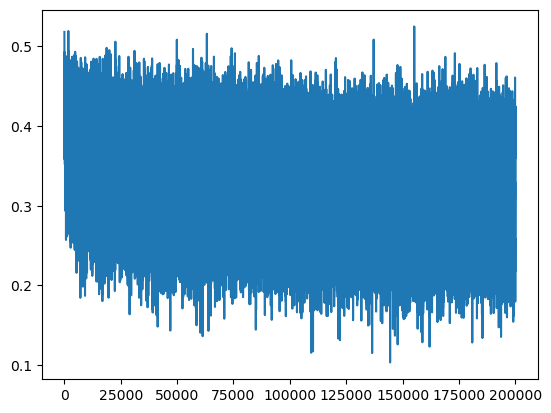

In [8]:
plt.plot(lossi)

In [9]:
with torch.no_grad():
    emb = C [Xtr]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 +B1

    bnmean  = hpreact.mean(0,keepdim=True)
    bnstd = hpreact.std(0,keepdim=True)
    

NameError: name 'B1' is not defined

In [ ]:
bnstd

In [ ]:
bnstd_running 

In [ ]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train':{Xtr,Ytr},
        'dev':{Xdev,Ydev},
        'test':{Xte,Yte}
    }[split]
    emb = C [x]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 + B1
    hpreact = bngains*(hpreact - bnmean_running)/bnstd_running+bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())
split_loss("train")
split_loss('dev')

In [ ]:
# sampling
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        # forward pass the neural nets
        emb = C [torch.tensor(context)]
        h = torch.tanh(emb.view(1,-1) @ W1 + B1)
        logits = h @ W2 + B2
        prob = F.softmax(logits,dim=1)
        # sample from the distribution
        ix = torch.multinomial(prob,num_samples=  1,generator = g ).item()
        #shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        if ix ==0 :
            break
    print(''.join(itos[i] for i in out))
        
        

# ---torchify the code ----

In [62]:
class Linear :
    def __init__(self,fan_in,fan_out,bias = True):
        self.weight = torch.randn((fan_in,fan_out),generator =g) / fan_in**0.5
        self.bias  =torch.randn((fan_out)) if bias else None
    def __call__(self,x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
        
class BatchNorm:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
        if self.training:
            xmean = x.mean(0,keepdim=True)
            xvar = x.var(0,keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar+self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
         with torch.no_grad():
            self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
            self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    def parameters(self):
        return [self.gamma,self.beta]
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size,n_embd), generator=g)
layers = [
    Linear(n_embd * block_size,n_hidden),BatchNorm(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),BatchNorm(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),BatchNorm(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),BatchNorm(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),BatchNorm(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),BatchNorm(vocab_size),
]
with torch.no_grad():
    # layers[-1].weight *= 0.1
    layers[-1].gamma *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight *= 5/3
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
        

47551


In [63]:
max_steps = 200000
batch_size = 32
lossi = []
ud =[]
for i in range(max_steps):

    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb ,Yb = Xtr[ix],Ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0],-1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x,Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    #update  
    lr =0.1 if i<10000 else 0.01
    for p in parameters:
        p.data += -lr*p.grad

    #track status
    if i % 1000 ==0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    if i>=1000:
       break

      0/ 200000 : 3.2870
   1000/ 200000 : 2.3105


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.62%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.47%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.16%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.81%
layer 14 (      Tanh): mean -0.00, std 0.65, saturated: 1.78%


Text(0.5, 1.0, 'activation distribution')

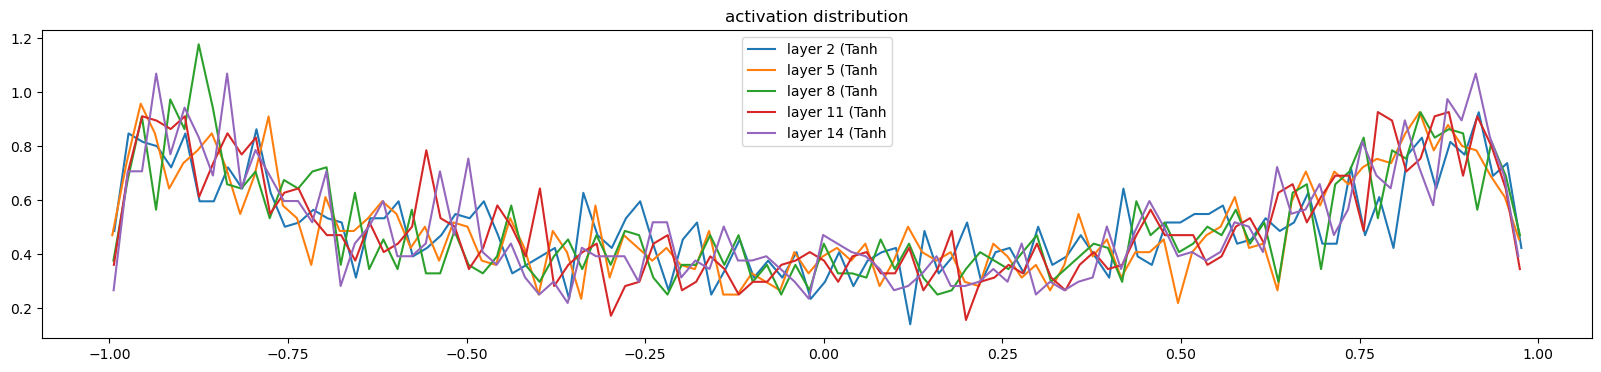

In [64]:
#visualize histogram
plt.figure(figsize=(20,4))
legends = []
for i,layer in enumerate(layers[:-1]):
    if isinstance(layer,Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')
    

layer 2 (      Tanh): mean -0.000000, std 3.682947e-03
layer 5 (      Tanh): mean -0.000000, std 3.262605e-03
layer 8 (      Tanh): mean -0.000000, std 2.973726e-03
layer 11 (      Tanh): mean +0.000000, std 2.741106e-03
layer 14 (      Tanh): mean -0.000000, std 2.584292e-03


Text(0.5, 1.0, 'gradient distribution')

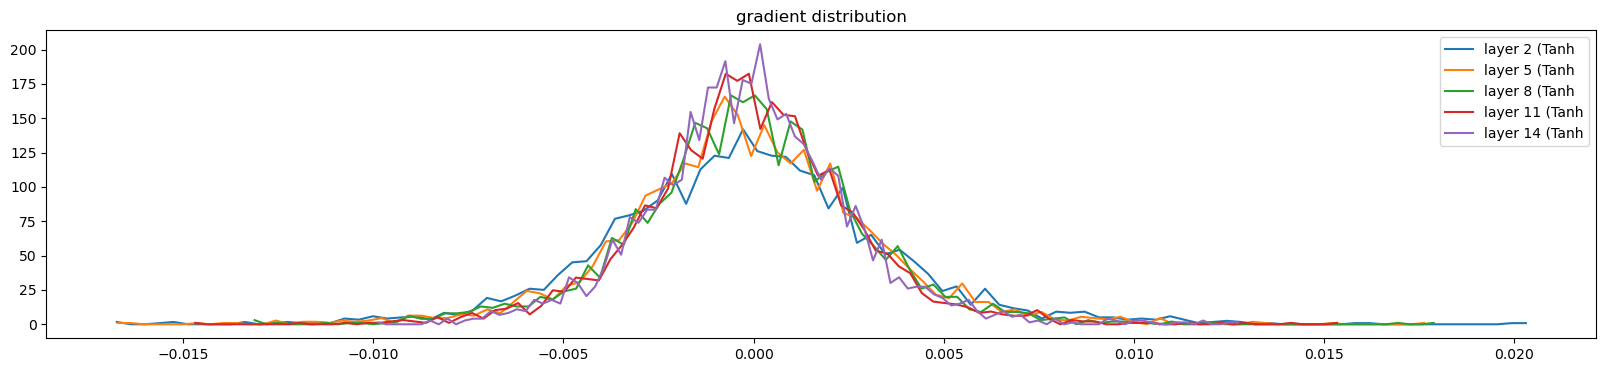

In [65]:
plt.figure(figsize=(20,4))
legends = []
for i,layer in enumerate(layers[:-1]):
    if isinstance(layer,Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        # print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))

        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.019882e-02 | grad:data ratio 1.018842e-02
weight  (30, 100) | mean +0.000092 | std 8.238413e-03 | grad:data ratio 2.635834e-02
weight (100, 100) | mean +0.000031 | std 7.318095e-03 | grad:data ratio 4.377134e-02
weight (100, 100) | mean -0.000019 | std 6.662019e-03 | grad:data ratio 3.949893e-02
weight (100, 100) | mean -0.000019 | std 5.821512e-03 | grad:data ratio 3.468158e-02
weight (100, 100) | mean +0.000053 | std 5.445289e-03 | grad:data ratio 3.243363e-02
weight  (100, 27) | mean -0.000165 | std 1.046843e-02 | grad:data ratio 6.281255e-02


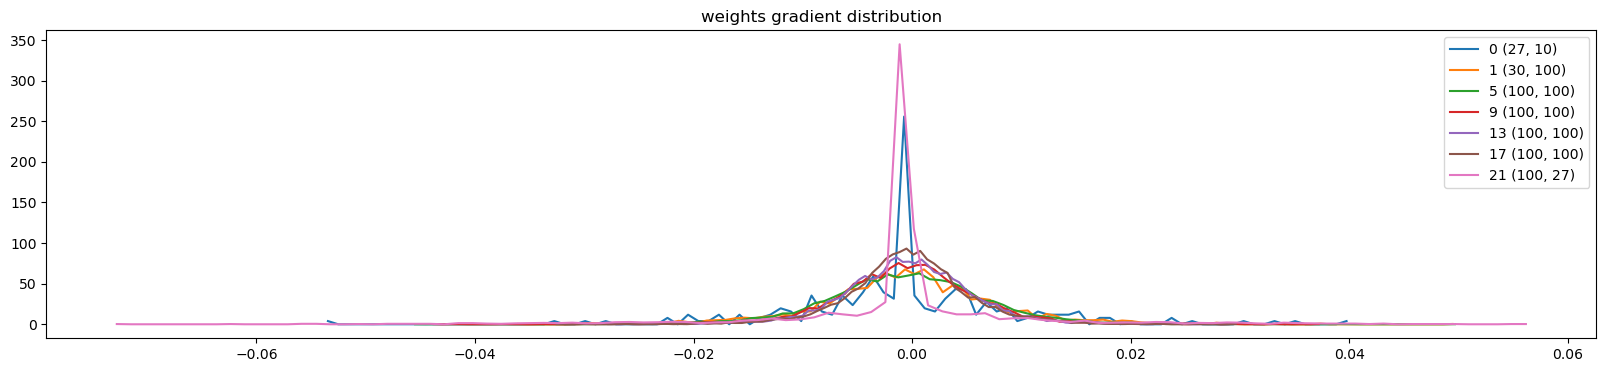

In [66]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

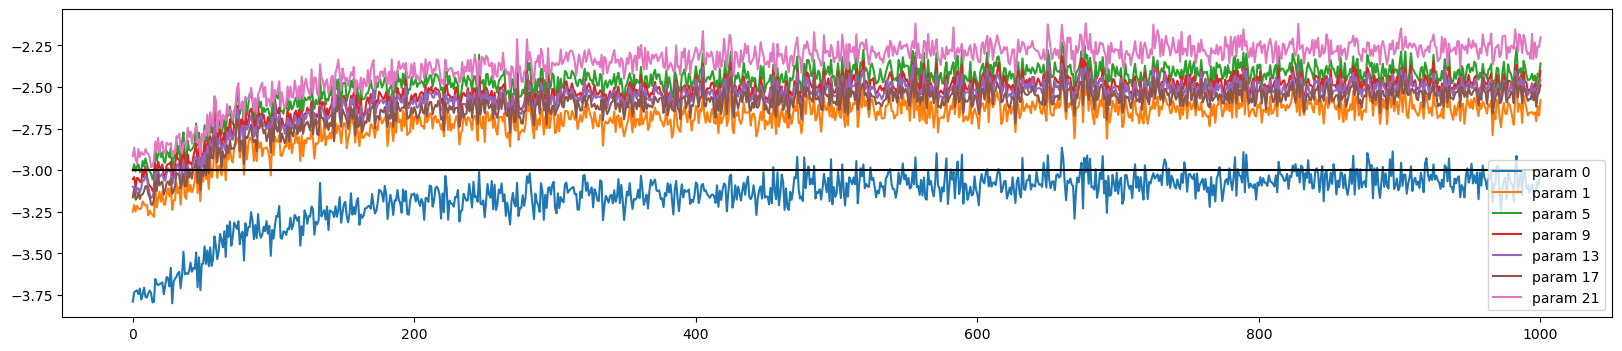

In [67]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);